Image loaded successfully.


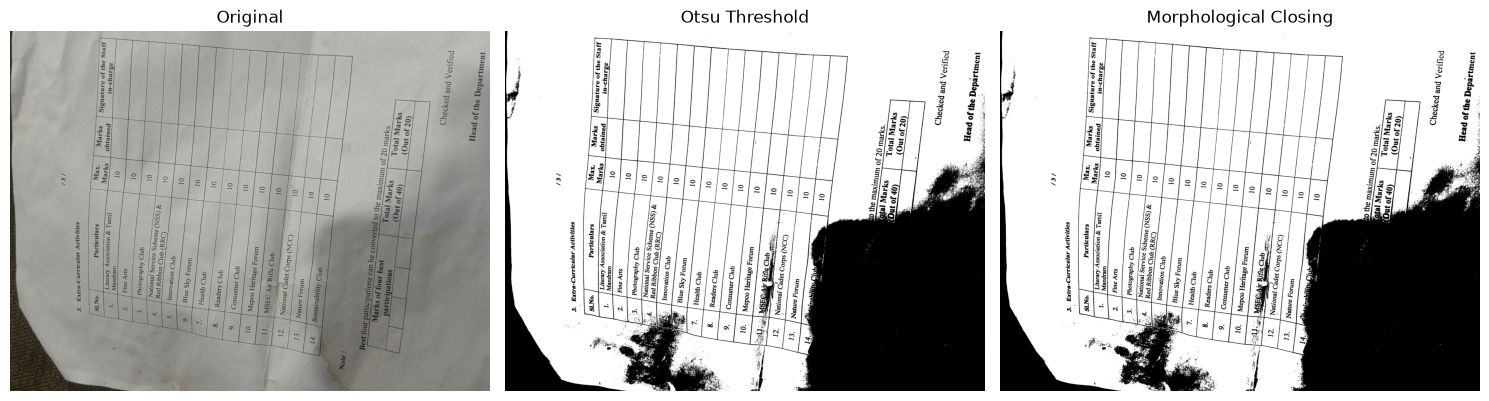

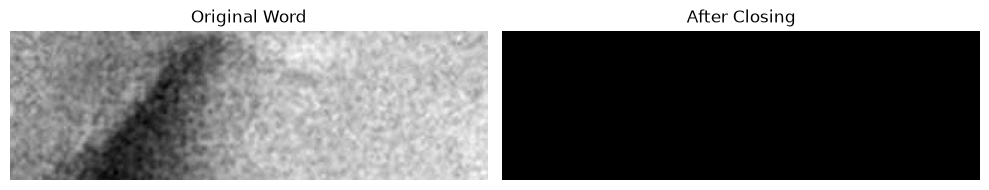

In [1]:
# Task 6: Thresholding and Morphology

## Aim

#To convert a document image into a binary image using Otsu's thresholding and improve the text quality using morphological closing.

## Theory

#Thresholding converts a grayscale image into a binary image by separating the foreground from the background.

#Otsu's Thresholding automatically calculates the optimal threshold value.

#Morphological Closing is a combination of dilation followed by erosion. It helps fill small gaps and holes in the text while keeping the characters connected.

import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("/Users/suriya/Documents/opencv/SuriyaKumar/raw_captures/document.jpg")

if img is None:
    print("Image not found.")
else:
    print("Image loaded successfully.")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

_, otsu = cv2.threshold(
    gray,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)
kernel = np.ones((3,3), np.uint8)

closing = cv2.morphologyEx(
    otsu,
    cv2.MORPH_CLOSE,
    kernel
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(otsu, cmap="gray")
plt.title("Otsu Threshold")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(closing, cmap="gray")
plt.title("Morphological Closing")
plt.axis("off")

plt.tight_layout()
plt.show()
# Change these values based on your image
crop_original = gray[120:220, 180:500]

crop_processed = closing[120:220, 180:500]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(crop_original, cmap="gray")
plt.title("Original Word")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(crop_processed, cmap="gray")
plt.title("After Closing")
plt.axis("off")

plt.tight_layout()
plt.show()

## Observation

#Otsu's thresholding successfully converted the document into a binary image without manually selecting a threshold value.

#Morphological closing removed small gaps within the text and made the characters appear more continuous.

#A 3×3 kernel worked well because it filled tiny gaps without merging neighboring letters. When a larger kernel was tested, some characters started to join together, reducing readability.

## Conclusion

#Otsu's thresholding automatically separated the text from the background. Morphological closing further improved the quality of the binary text by filling small gaps, making the document easier to read.